Aula 03

In [1]:
import psycopg2
from config import DB_CONFIG
# está importando partes específicas da biblioteca SQLAlchemy, e não a biblioteca inteira.
from sqlalchemy import create_engine, URL, Column, String, Integer, Boolean, ForeignKey
#recursos da parte ORM do SQLAlchemy
from sqlalchemy.orm import sessionmaker, declarative_base

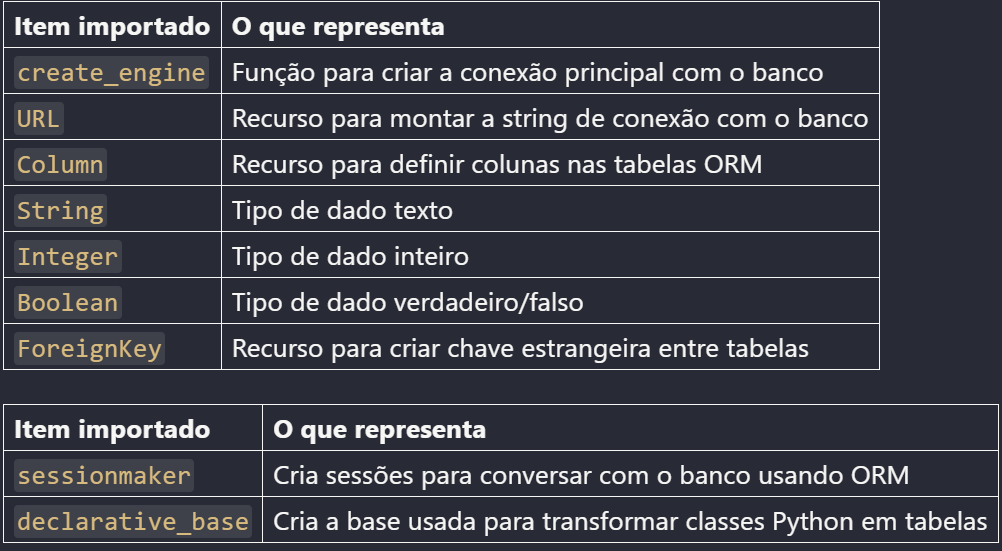

In [2]:
# 01 Criar banco aula03

conexao = psycopg2.connect(
    host=DB_CONFIG["host"],
    database="postgres",
    user=DB_CONFIG["user"],
    password=DB_CONFIG["password"],
    port=DB_CONFIG["port"]
)

# necessário para executar CREATE DATABASE
conexao.autocommit = True

cursor = conexao.cursor()

# verifica se o banco aula03 já existe
cursor.execute("SELECT 1 FROM pg_database WHERE datname = 'aula03';")
banco_existe = cursor.fetchone()

if banco_existe:
    print("O banco aula03 já existe.")
else:
    cursor.execute("CREATE DATABASE aula03;")
    print("Banco aula03 criado com sucesso.")

cursor.close()
conexao.close()

print("Conexão com o banco postgres encerrada.")

O banco aula03 já existe.
Conexão com o banco postgres encerrada.


In [3]:
# 02 Criar conexão com o banco aula03 usando SQLALCHEMY

url_conexao = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_CONFIG["user"],
    password=DB_CONFIG["password"],
    host=DB_CONFIG["host"],
    port=DB_CONFIG["port"],
    database="aula03" # alterando para aula03
)

engine = create_engine(url_conexao)

# SESSÃO É UMA CONEXÃO TEMPORÁRIA, POSTERIORMENTE VAMOS PRECISAR FECHAR ESSA SESSÃO.
Session = sessionmaker(bind=engine)
session = Session()

#Cria a base usada para mapear classes Python como tabelas do banco.
Base = declarative_base()

In [4]:
# 03 Mapear tabela "Usuarios" como uma classe em python

class Usuario(Base): #Define a classe Usuario.
       __tablename__ = "usuarios" #Define o nome da tabela no banco. A classe Usuario está ligada à tabela chamada usuarios.
       #são atributos da classe Usuario(id, nome, email, senha, ativo)
       id = Column(Integer, primary_key= True, autoincrement= True)
       nome = Column(String(100))
       email = Column(String(255))
       senha = Column(String(100))
       ativo = Column(Boolean)

       #Define o método especial __init__ (método construtor da classe que inicializa o objeto).
       def __init__(self, nome, email, senha, ativo=True):

              #atributos do objeto
              self.nome = nome # Guarda o valor recebido no parâmetro 'nome' dentro do objeto.
              self.email = email
              self.senha = senha
              self.ativo = ativo

In [5]:
# 04 Mapear a tabela livros

class Livro(Base):
    __tablename__ = "livros"

    id = Column(Integer, primary_key=True, autoincrement=True)
    titulo = Column(String(150))
    qtde_paginas = Column(Integer)
    dono = Column(Integer, ForeignKey("usuarios.id")) #A coluna dono, da tabela livros, só pode receber valores que já existam na coluna id da tabela usuarios.

    def __init__(self, titulo, qtde_paginas, dono):
        self.titulo = titulo
        self.qtde_paginas = qtde_paginas
        self.dono = dono

In [ ]:
# 05 Criar tabelas

#CRIAR A TABELA usuarios

Usuario.__table__.create(bind=engine, checkfirst=True)#bind=engine: engine é o objeto que representa a conexão com o PostgreSQL,
#checkfirst=True: verifica se ela já existe.
print("Tabela usuarios criada com sucesso no banco aula03.")

# CRIAR A TABELA livros

Livro.__table__.create(bind=engine, checkfirst=True)

print("Tabela livros criada com sucesso no banco aula03.")

Tabela usuarios criada com sucesso no banco aula03.
Tabela livros criada com sucesso no banco aula03.


In [7]:
#06 Inserir dados usuarios

usuario_01 = Usuario( #usuario_01 → objeto da classe Usuario
    nome="Joao Silva", # Define o valor do atributo 'nome' desse objeto
    email="joao@email.com",
    senha="123456",
    ativo=True
)

usuario_02 = Usuario(
    nome="Maria Souza",
    email="maria@email.com",
    senha="abc123",
    ativo=True
)
session.add(usuario_01) #Adiciona o objeto usuario_01 à sessão.
session.add(usuario_02) # Adiciona o objeto usuario_02 à sessão.
session.commit() #Confirma a operação no banco de dados.


print("Usuários inseridos com sucesso.")

Usuários inseridos com sucesso.


In [8]:
#  07 #06 Inserir dados livros

livro_01 = Livro(
    titulo="Nome do Vento",
    qtde_paginas=1000,
    #dono=usuario_01.id
    dono=1
)

livro_02 = Livro(
    titulo="Python para Dados",
    qtde_paginas=350,
    #dono=usuario_02.id
    dono=2
)

session.add(livro_01)
session.add(livro_02)
session.commit()

print("Livros inseridos com sucesso.")

Livros inseridos com sucesso.


In [9]:
# 08 Encerrar a sessão

session.close()
engine.dispose()

print("Sessão encerrada.")
print("Engine finalizada.")

Sessão encerrada.
Engine finalizada.
